In [1]:
import pandas as pd
from pathlib import Path

PRELABELED_RUN = Path("/Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Task02/Task02_PreLabeledDataset/Results/Models/YOLO_Results/yolo11n_test_run")
CUSTOM_RUN = Path("/Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Task02/Task02_CustomDataset/Results/YOLO_Results/yolo11n_test_run")

pre_csv = PRELABELED_RUN / "results.csv"
cus_csv = CUSTOM_RUN / "results.csv"

pre_df = pd.read_csv(pre_csv)
cus_df = pd.read_csv(cus_csv)

pre_df.columns = [c.strip() for c in pre_df.columns]
cus_df.columns = [c.strip() for c in cus_df.columns]

metric_cols = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

summary = pd.DataFrame({
    "Model": [
        "YOLO11n fine-tuned prelabelled",
        "YOLO11n fine-tuned custom"
    ],
    "Best Precision": [
        pre_df["metrics/precision(B)"].max(),
        cus_df["metrics/precision(B)"].max()
    ],
    "Best Recall": [
        pre_df["metrics/recall(B)"].max(),
        cus_df["metrics/recall(B)"].max()
    ],
    "Best mAP50": [
        pre_df["metrics/mAP50(B)"].max(),
        cus_df["metrics/mAP50(B)"].max()
    ],
    "Best mAP50-95": [
        pre_df["metrics/mAP50-95(B)"].max(),
        cus_df["metrics/mAP50-95(B)"].max()
    ],
    "Final Precision": [
        pre_df["metrics/precision(B)"].iloc[-1],
        cus_df["metrics/precision(B)"].iloc[-1]
    ],
    "Final Recall": [
        pre_df["metrics/recall(B)"].iloc[-1],
        cus_df["metrics/recall(B)"].iloc[-1]
    ],
    "Final mAP50": [
        pre_df["metrics/mAP50(B)"].iloc[-1],
        cus_df["metrics/mAP50(B)"].iloc[-1]
    ],
    "Final mAP50-95": [
        pre_df["metrics/mAP50-95(B)"].iloc[-1],
        cus_df["metrics/mAP50-95(B)"].iloc[-1]
    ]
})

summary = summary.round(4)
print(summary)

                            Model  Best Precision  Best Recall  Best mAP50  \
0  YOLO11n fine-tuned prelabelled          0.9877       0.8453      0.6440   
1       YOLO11n fine-tuned custom          0.9804       0.9949      0.9883   

   Best mAP50-95  Final Precision  Final Recall  Final mAP50  Final mAP50-95  
0         0.4092           0.4737        0.6401       0.6120          0.3914  
1         0.8733           0.9799        0.9927       0.9883          0.8733  


In [2]:
pre_best_map50 = pre_df["metrics/mAP50(B)"].max()
cus_best_map50 = cus_df["metrics/mAP50(B)"].max()

pre_best_map = pre_df["metrics/mAP50-95(B)"].max()
cus_best_map = cus_df["metrics/mAP50-95(B)"].max()

pre_best_precision = pre_df["metrics/precision(B)"].max()
cus_best_precision = cus_df["metrics/precision(B)"].max()

pre_best_recall = pre_df["metrics/recall(B)"].max()
cus_best_recall = cus_df["metrics/recall(B)"].max()

print("YOLO11n fine-tuned prelabelled:")
print("  Best Precision  :", round(pre_best_precision, 4))
print("  Best Recall     :", round(pre_best_recall, 4))
print("  Best mAP50      :", round(pre_best_map50, 4))
print("  Best mAP50-95   :", round(pre_best_map, 4))
print()

print("YOLO11n fine-tuned custom:")
print("  Best Precision  :", round(cus_best_precision, 4))
print("  Best Recall     :", round(cus_best_recall, 4))
print("  Best mAP50      :", round(cus_best_map50, 4))
print("  Best mAP50-95   :", round(cus_best_map, 4))
print()

if cus_best_map > pre_best_map:
    print("Custom dataset model performed better in mAP50-95.")
else:
    print("Prelabelled dataset model performed better in mAP50-95.")

if cus_best_map50 > pre_best_map50:
    print("Custom dataset model performed better in mAP50.")
else:
    print("Prelabelled dataset model performed better in mAP50.")

YOLO11n fine-tuned prelabelled:
  Best Precision  : 0.9877
  Best Recall     : 0.8453
  Best mAP50      : 0.644
  Best mAP50-95   : 0.4092

YOLO11n fine-tuned custom:
  Best Precision  : 0.9804
  Best Recall     : 0.9949
  Best mAP50      : 0.9883
  Best mAP50-95   : 0.8733

Custom dataset model performed better in mAP50-95.
Custom dataset model performed better in mAP50.


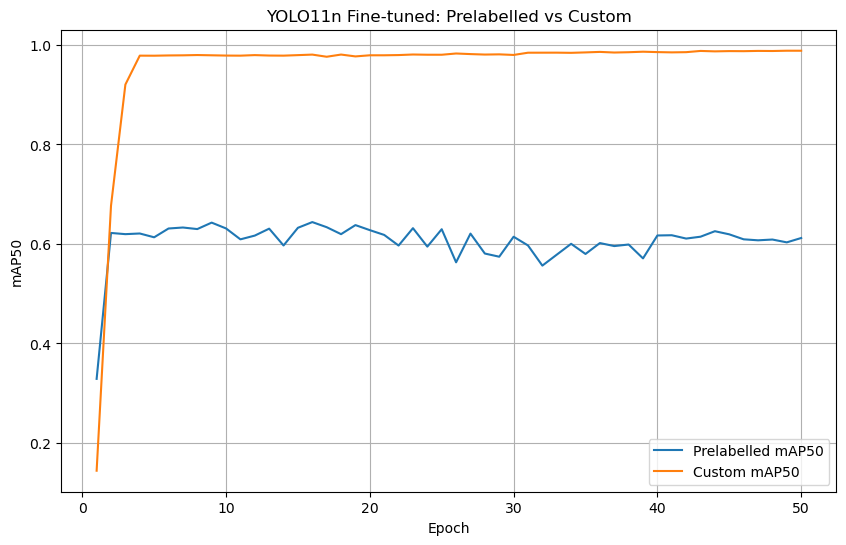

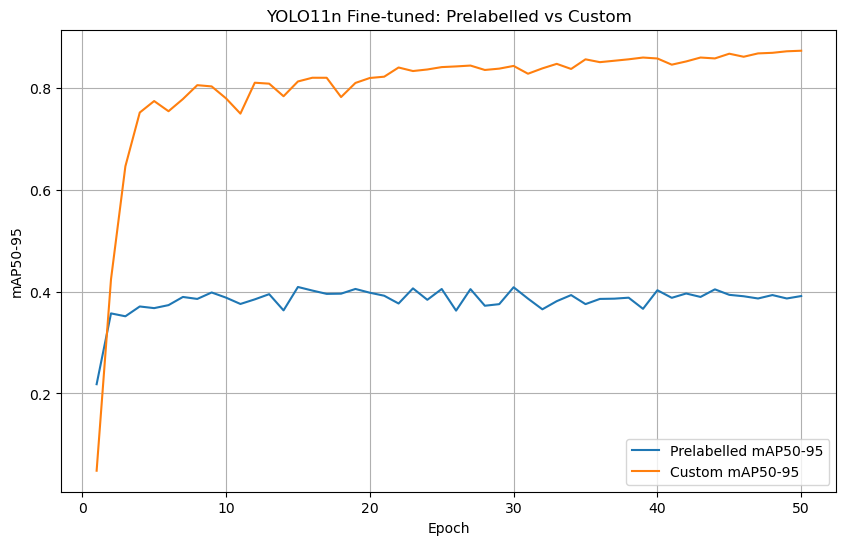

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(pre_df["epoch"], pre_df["metrics/mAP50(B)"], label="Prelabelled mAP50")
plt.plot(cus_df["epoch"], cus_df["metrics/mAP50(B)"], label="Custom mAP50")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("YOLO11n Fine-tuned: Prelabelled vs Custom")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(pre_df["epoch"], pre_df["metrics/mAP50-95(B)"], label="Prelabelled mAP50-95")
plt.plot(cus_df["epoch"], cus_df["metrics/mAP50-95(B)"], label="Custom mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("YOLO11n Fine-tuned: Prelabelled vs Custom")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
report_table = pd.DataFrame({
    "Model": [
        "YOLO11n fine-tuned prelabelled",
        "YOLO11n fine-tuned custom"
    ],
    "mAP50": [
        pre_df["metrics/mAP50(B)"].max(),
        cus_df["metrics/mAP50(B)"].max()
    ],
    "mAP50-95": [
        pre_df["metrics/mAP50-95(B)"].max(),
        cus_df["metrics/mAP50-95(B)"].max()
    ],
    "Precision": [
        pre_df["metrics/precision(B)"].max(),
        cus_df["metrics/precision(B)"].max()
    ],
    "Recall": [
        pre_df["metrics/recall(B)"].max(),
        cus_df["metrics/recall(B)"].max()
    ]
}).round(4)

report_table

,Model,mAP50,mAP50-95,Precision,Recall
0,YOLO11n fine-tuned prelabelled,0.6440,0.4092,0.9877,0.8453
1,YOLO11n fine-tuned custom,0.9883,0.8733,0.9804,0.9949
